# Exploration des données MovieLens

Notebook de visualisation du dataset **MovieLens** (dossier `Data/`).

| Fichier | Description | Colonnes |
|---|---|---|
| `rating.csv` | Notes des utilisateurs (~20M lignes, 690 Mo) | userId, movieId, rating, timestamp |
| `movie.csv` | Films | movieId, title, genres |
| `tag.csv` | Tags libres posés par les users | userId, movieId, tag, timestamp |
| `link.csv` | Liens IMDb / TMDb | movieId, imdbId, tmdbId |
| `genome_scores.csv` | Pertinence tag-film (~15M lignes, 214 Mo) | movieId, tagId, relevance |
| `genome_tags.csv` | Libellés des tags du genome | tagId, tag |

**Dépendances :** `pip install pandas numpy matplotlib seaborn`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA = Path("Data")
assert DATA.exists(), "Dossier Data/ introuvable — lance le notebook depuis la racine du projet"
print("Fichiers :", [p.name for p in DATA.glob('*.csv')])

Fichiers : ['rating.csv', 'tag.csv', 'genome_scores.csv', 'genome_tags.csv', 'link.csv', 'movie.csv']


## 1. Films (`movie.csv`)

In [2]:
movies = pd.read_csv(DATA / "movie.csv")
print(f"{len(movies):,} films")

# Année extraite du titre « Titre (AAAA) »
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype("float")
movies.head()

27,278 films


,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0


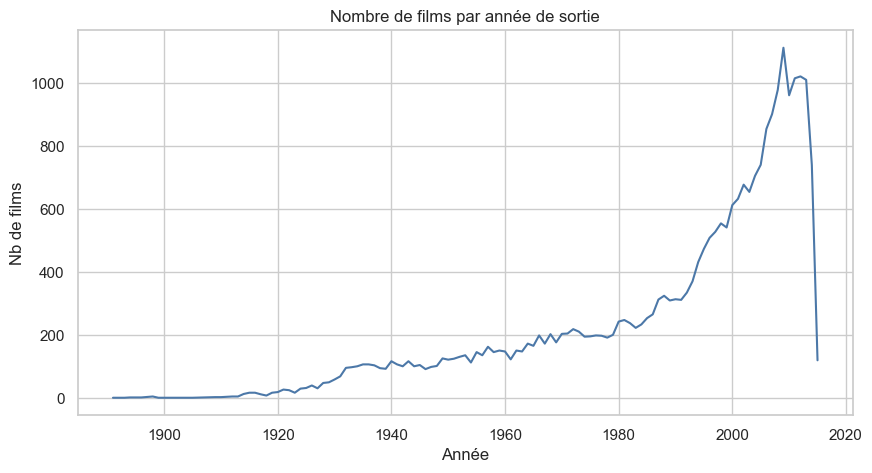

In [3]:
# Répartition des films par année de sortie
ax = movies["year"].dropna().astype(int).value_counts().sort_index().plot(
    kind="line", color="#4C78A8"
)
ax.set(title="Nombre de films par année de sortie", xlabel="Année", ylabel="Nb de films")
plt.show()

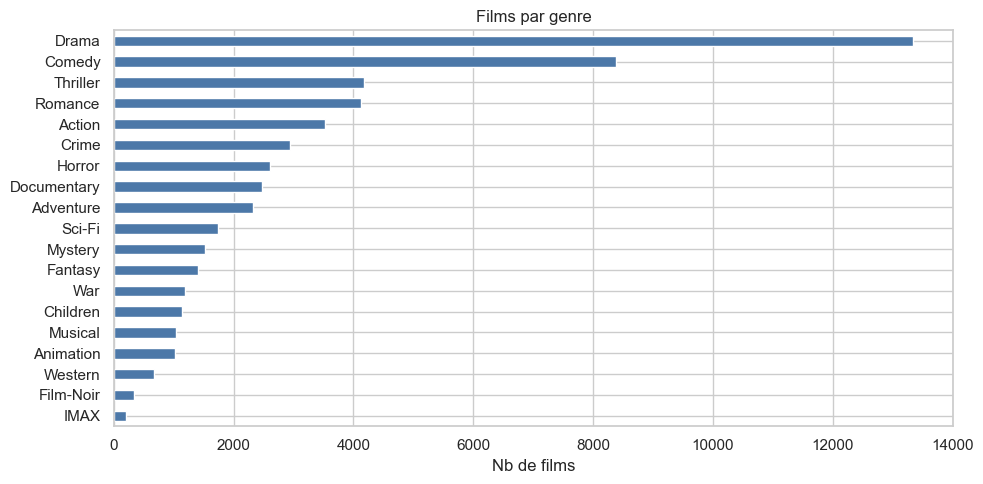

In [4]:
# Genres les plus fréquents (un film a plusieurs genres séparés par |)
genres = movies["genres"].str.get_dummies(sep="|")
genre_counts = genres.sum().sort_values(ascending=False)
genre_counts = genre_counts.drop("(no genres listed)", errors="ignore")

ax = genre_counts.plot(kind="barh", color="#4C78A8")
ax.invert_yaxis()
ax.set(title="Films par genre", xlabel="Nb de films")
plt.tight_layout(); plt.show()

## 2. Notes (`rating.csv`)

Fichier volumineux (~20M lignes). On charge un **échantillon aléatoire** pour les visualisations, et on calcule quelques stats globales par streaming (chunks).

In [5]:
# Échantillon : ~1 ligne sur 20 (fixé par un seed reproductible)
rng = np.random.default_rng(42)
ratings = pd.read_csv(
    DATA / "rating.csv",
    parse_dates=["timestamp"],
    skiprows=lambda i: i > 0 and rng.random() > 0.05,
)
print(f"Échantillon : {len(ratings):,} notes")
ratings.head()

Échantillon : 999,051 notes


,userId,movieId,rating,timestamp
0,1,1097,4.0,2005-04-02 23:48:21
1,1,1304,3.0,2004-09-10 03:08:40
2,1,2021,4.0,2005-04-02 23:52:09
3,1,2648,3.5,2004-09-10 03:13:37
4,1,4754,4.0,2005-04-02 23:36:23


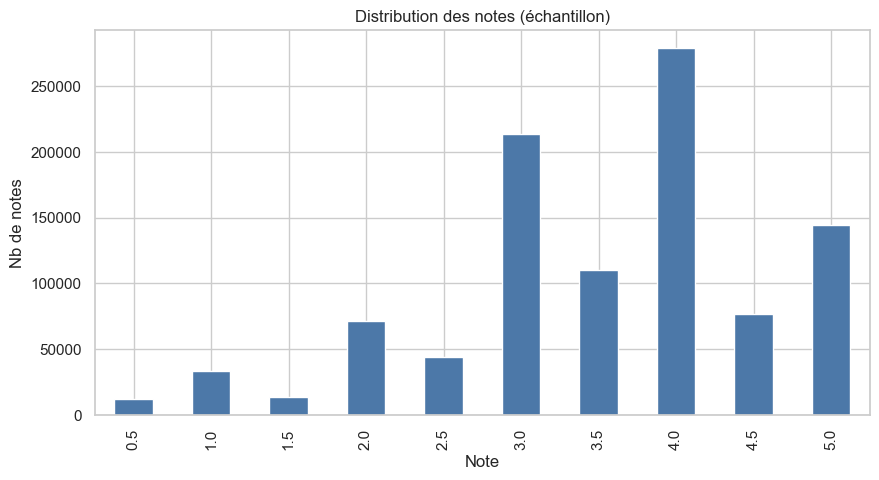

count    999051.000000
mean          3.526362
std           1.051408
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [6]:
# Distribution des notes
ax = ratings["rating"].value_counts().sort_index().plot(kind="bar", color="#4C78A8")
ax.set(title="Distribution des notes (échantillon)", xlabel="Note", ylabel="Nb de notes")
plt.show()

print(ratings["rating"].describe())

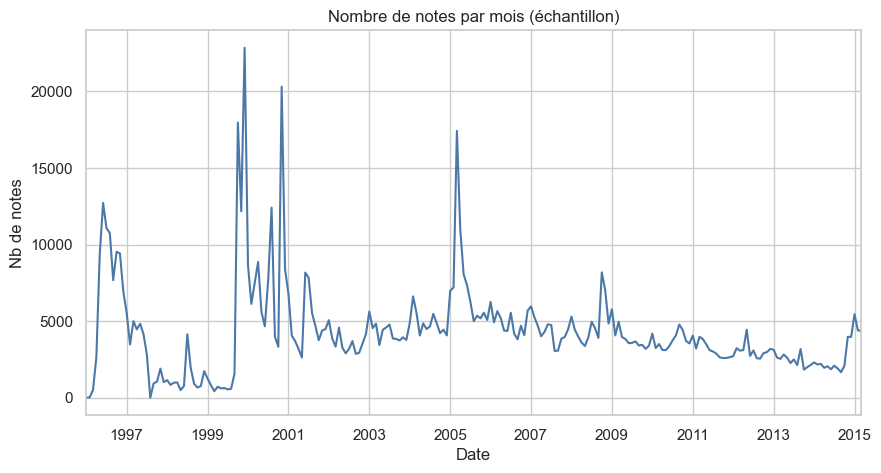

In [7]:
# Volume de notes dans le temps
by_month = ratings.set_index("timestamp").resample("MS").size()
ax = by_month.plot(color="#4C78A8")
ax.set(title="Nombre de notes par mois (échantillon)", xlabel="Date", ylabel="Nb de notes")
plt.show()

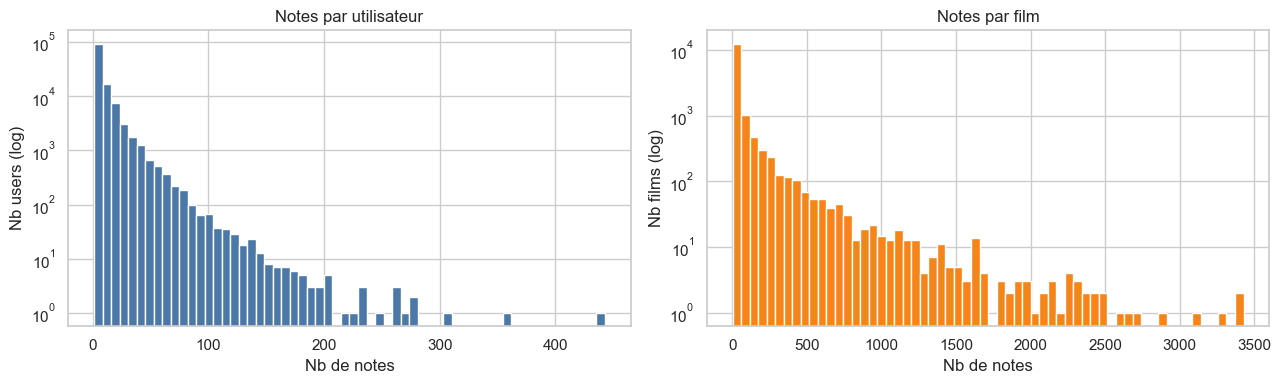

In [8]:
# Activité par utilisateur et popularité par film (échantillon)
per_user = ratings.groupby("userId").size()
per_movie = ratings.groupby("movieId").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
per_user.plot(kind="hist", bins=60, log=True, ax=axes[0], color="#4C78A8")
axes[0].set(title="Notes par utilisateur", xlabel="Nb de notes", ylabel="Nb users (log)")
per_movie.plot(kind="hist", bins=60, log=True, ax=axes[1], color="#F58518")
axes[1].set(title="Notes par film", xlabel="Nb de notes", ylabel="Nb films (log)")
plt.tight_layout(); plt.show()

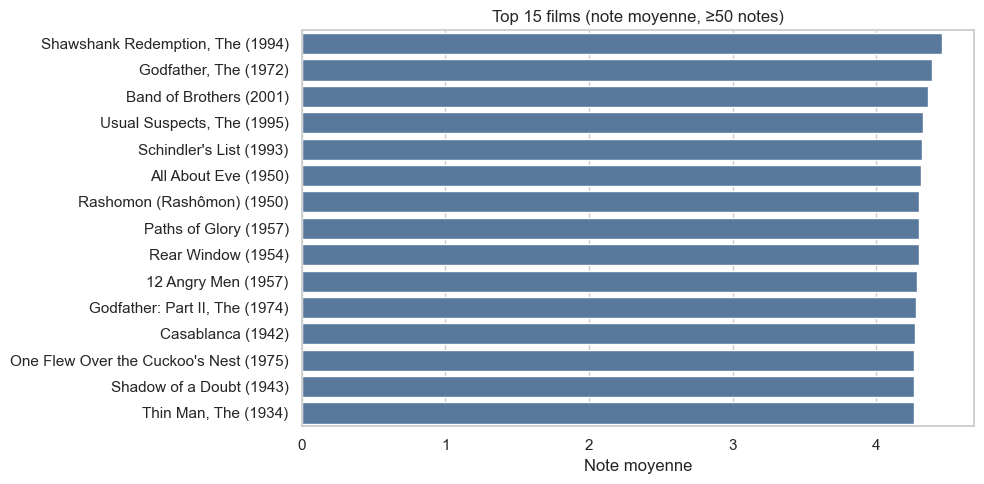

In [9]:
# Top 15 films les mieux notés (min. 50 notes dans l'échantillon)
stats = ratings.groupby("movieId")["rating"].agg(["mean", "count"])
top = stats[stats["count"] >= 50].sort_values("mean", ascending=False).head(15)
top = top.merge(movies[["movieId", "title"]], on="movieId")

ax = sns.barplot(data=top, y="title", x="mean", color="#4C78A8")
ax.set(title="Top 15 films (note moyenne, ≥50 notes)", xlabel="Note moyenne", ylabel="")
plt.tight_layout(); plt.show()

## 3. Tags (`tag.csv`)

465,564 tags | 38,643 tags distincts


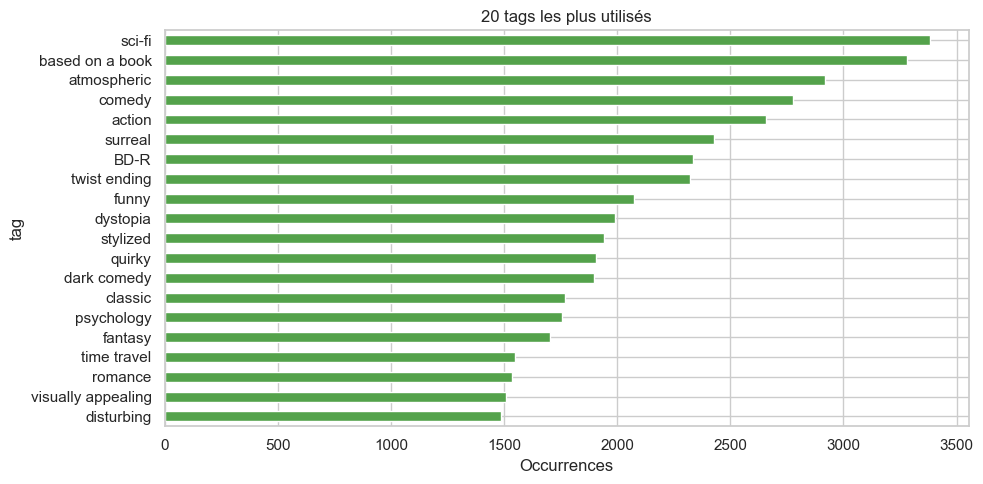

In [10]:
tags = pd.read_csv(DATA / "tag.csv")
print(f"{len(tags):,} tags | {tags['tag'].nunique():,} tags distincts")

top_tags = tags["tag"].value_counts().head(20)
ax = top_tags.plot(kind="barh", color="#54A24B")
ax.invert_yaxis()
ax.set(title="20 tags les plus utilisés", xlabel="Occurrences")
plt.tight_layout(); plt.show()

## 4. Tag genome (`genome_scores.csv` + `genome_tags.csv`)

Scores de pertinence [0,1] entre chaque film et ~1100 tags. Fichier volumineux : on charge par chunks pour un aperçu.

1,128 tags dans le genome


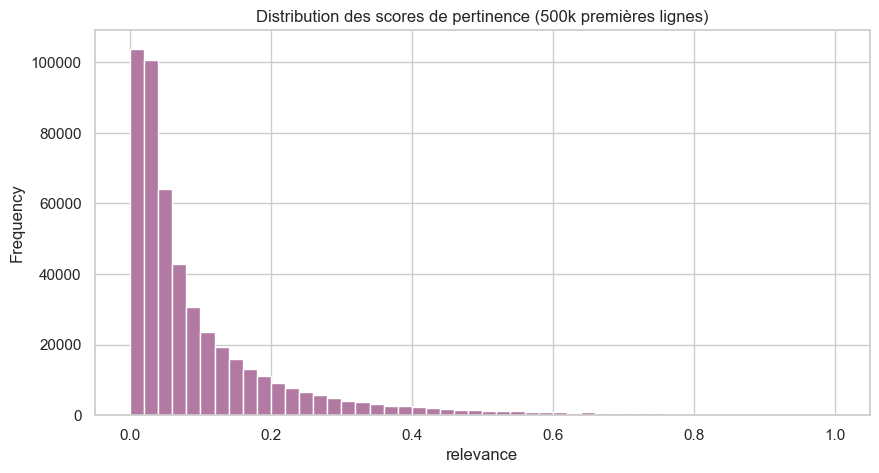

In [11]:
genome_tags = pd.read_csv(DATA / "genome_tags.csv")
print(f"{len(genome_tags):,} tags dans le genome")

# Distribution des scores de pertinence sur un échantillon
sample = pd.read_csv(DATA / "genome_scores.csv", nrows=500_000)
ax = sample["relevance"].plot(kind="hist", bins=50, color="#B279A2")
ax.set(title="Distribution des scores de pertinence (500k premières lignes)", xlabel="relevance")
plt.show()

## 5. Synthèse

Récapitulatif des volumes du dataset.

In [12]:
summary = {
    "Films": len(movies),
    "Users (échantillon)": ratings["userId"].nunique(),
    "Notes (échantillon)": len(ratings),
    "Tags": len(tags),
    "Tags genome": len(genome_tags),
}
pd.Series(summary).to_frame("count")

,count
Films,27278
Users (échantillon),125716
Notes (échantillon),999051
Tags,465564
Tags genome,1128
